
## 一、核心业务背景
- **分析对象**：大区下5个城市（A/B/C/D/E）的网约车运营数据
- **核心流程**：`冒泡 → 呼叫 → 应答 → 完单`
- **分析目标**：对比各城市运营效率，定位问题根因，提出优化策略
- **数据维度**：
  - 分类变量：城市、星期（工作日/休息日）、时段（0~23点）
  - 连续变量：冒泡数、呼叫数、应答数、完单数、司机在线数

---

## 二、核心分析方法论
### 1. 多维度分析方法
| 方法 | 核心逻辑 | 适用场景 |
|------|----------|----------|
| **钻取分析** | 从总体到细分，逐层深入（大区→城市→星期→时段） | 定位问题根因，从宏观到微观 |
| **切片/切块分析** | 按维度切割数据，单维度/两维度组合分析 | 观察特定子集，探索维度间关系 |
| **数据透视/可视化** | 交叉表格+图表，灵活组合维度与指标 | 发现趋势、异常与规律 |

### 2. 指标关系梳理
- **并列关系**：城市与城市之间、每天/每时情况之间
- **包含关系**：大区→城市、周→日→小时
- **流程关系**：`冒泡 → 呼叫 → 应答 → 完单`（核心转化漏斗）

### 3. 黄金分析顺序：从大到小，从尾到头
- **从大到小**：先看大区整体，再看城市，再看星期/时段
- **从尾到头**：先看结果指标（完单数），再看过程指标（冒泡/呼叫/应答）

---



## 三、完整分析步骤与代码

### 3.1 数据读取与基础汇总

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('网约车城市运营情况.xlsx')

In [2]:
df.head(5)

,星期,时段,城市,冒泡数,呼叫数,应答数,完单数,司机在线
0,周一,0,A市,29618,12616,11388,11276,13700
1,周一,1,A市,17822,7851,7025,6890,9217
2,周一,2,A市,12524,5616,4864,4747,6641
3,周一,3,A市,7232,3166,2724,2199,4939
4,周一,4,A市,6213,2447,1999,1794,4071


## 3.2 各城市完单情况分析（结果指标）

In [3]:
city_finish_num =df.groupby(['城市'])['完单数'].sum().reset_index()

# 按照完单数从高到低排列
city_finish_num.sort_values(by = '完单数',ascending = False,inplace = True)
# 计算整体平均值
city_finish_num['平均值'] = round(np.mean(city_finish_num['完单数']))
# 将各城市的完单数除以平均值
city_finish_num['完单数/平均值(%)'] = round((city_finish_num['完单数']/city_finish_num['平均值'])*100)

city_finish_num

,城市,完单数,平均值,完单数/平均值(%)
2,C市,3957520,3665949,108.0
3,D市,3655778,3665949,100.0
0,A市,3619113,3665949,99.0
1,B市,3610821,3665949,98.0
4,E市,3486512,3665949,95.0


- 初步结论：
    - **C** 市完单数最高（+8%），**E**市最低（-5%）
    - 仅看完单数不够，需结合过程指标与司机供给

## 3.3 各城市过程指标分析（效率与供给）

In [4]:
# 计算每个城市的
city_bubble_num = df.groupby('城市')['冒泡数'].sum().reset_index()
city_call_num = df.groupby('城市')['呼叫数'].sum().reset_index()
city_answer_num = df.groupby('城市')['应答数'].sum().reset_index()
city_driver_num = df.groupby('城市')['司机在线'].sum().reset_index()

# 拼接表格
lists = [city_bubble_num, city_call_num, city_answer_num, city_driver_num]
result = city_finish_num.drop(columns = ['平均值'])

for table in lists:
    result = result.merge(table,on = '城市')

result['人均完单量'] = round(result['完单数']/result['司机在线'],2)
result

,城市,完单数,完单数/平均值(%),冒泡数,呼叫数,应答数,司机在线,人均完单量
0,C市,3957520,108.0,7244300,4850460,4621680,2457820,1.61
1,D市,3655778,100.0,10436933,4393449,4027468,3726086,0.98
2,A市,3619113,99.0,11341762,4708803,4126801,4227979,0.86
3,B市,3610821,98.0,8493957,4358118,4222191,3940414,0.92
4,E市,3486512,95.0,10990002,4384481,4029768,3836432,0.91


In [5]:
# 冒泡数vs平均值
result['冒泡数平均值'] = round(np.mean(result['冒泡数']))
result['冒泡数/平均值(%)'] = round((result['冒泡数']/result['冒泡数平均值'])*100,2)

# 呼叫数VS平均值
result['呼叫数均值'] = round(np.mean(result['呼叫数']))
result['呼叫数/平均值(%)'] = round((result['呼叫数']/result['呼叫数均值'])*100)

# 司机在线数VS平均值
result['司机在线均值'] = round(np.mean(result['司机在线']))
result['司机在线/平均值（%）'] = round((result['司机在线']/result['司机在线均值'])*100)

# 每人次订单数VS平均值
result['总体完单量均值'] = round(np.mean(result['人均完单量']))
result['人均完单量/平均值(%)'] = round(result['人均完单量']/result['总体完单量均值']*100)

result[['城市','完单数/平均值(%)','冒泡数/平均值(%)','呼叫数/平均值(%)','司机在线/平均值（%）','人均完单量/平均值(%)']]

,城市,完单数/平均值(%),冒泡数/平均值(%),呼叫数/平均值(%),司机在线/平均值（%）,人均完单量/平均值(%)
0,C市,108.0,74.67,107.0,68.0,161.0
1,D市,100.0,107.58,97.0,102.0,98.0
2,A市,99.0,116.91,104.0,116.0,86.0
3,B市,98.0,87.55,96.0,108.0,92.0
4,E市,95.0,113.28,97.0,105.0,91.0


**关键发现**：
- C 市：冒泡数 / 司机在线数低于平均，但**人均完单量最高（效率之王）**
- A 市：冒泡数 / 司机在线数高于平均，但**人均完单量最低（需求未转化）**

## 3.4 转化率分析（漏斗拆解）

In [6]:
result['最终转化率%'] = round(result['完单数']/result['冒泡数'],2)
result['呼叫率%'] = round(result['呼叫数']/result['冒泡数'],2)
result['应答率%'] = round(result['应答数']/result['呼叫数'],2)
result['完单率%'] = round(result['完单数']/result['应答数'],2)
result = result.sort_values(by = '最终转化率%',ascending = False)
result[['城市','呼叫率%','应答率%','完单率%','最终转化率%']]

,城市,呼叫率%,应答率%,完单率%,最终转化率%
0,C市,0.67,0.95,0.86,0.55
3,B市,0.51,0.97,0.86,0.43
1,D市,0.42,0.92,0.91,0.35
2,A市,0.42,0.88,0.88,0.32
4,E市,0.40,0.92,0.87,0.32


核心结论：
- **C市**：**呼叫率 / 应答率高**，最终转化率 55%**（最优）**
- **A市**：**呼叫率 / 应答率低**，最终转化率 **32%（最差）**
- 问题定位：**A市需求未转化，C 市效率极高**

## 3.5 钻取分析：A/C 市周维度对比

In [7]:
#筛选城市A和C
ca_city= df[df['城市'].isin(['A市','C市'])]
# 分组顺序，先按星期，再按城市
ca_data = ca_city.groupby(['星期','城市'])[['冒泡数','呼叫数','应答数','完单数']].agg('sum')
ca_data = ca_data.reset_index()

# 指定星期列为Categorical类型，并按照指定顺序排序
week_order = ['周一','周二','周三','周四','周五','周六','周日']
ca_data['星期'] = pd.Categorical(ca_data['星期'],categories = week_order,ordered=True)
ca_data = ca_data.sort_values('星期')
ca_data.head()

,星期,城市,冒泡数,呼叫数,应答数,完单数
0,周一,A市,1434468,618654,540087,478519
1,周一,C市,1048900,693320,664440,564920
4,周二,A市,1401869,589862,527823,458663
5,周二,C市,1249360,811740,721640,607780
2,周三,A市,1431230,596027,533182,471404


In [10]:
ca_data['呼叫率'] = round(ca_data['呼叫数']/ca_data['冒泡数'],2)
ca_data['应答率'] = round(ca_data['应答数']/ca_data['呼叫数'],2)
ca_data['完单率'] = round(ca_data['完单数']/ca_data['应答数'],2)
ca_data['最终转化率'] = round(ca_data['完单数']/ca_data['呼叫率'],2)
a_data = ca_data.query('城市=="A市"')[['星期','城市','呼叫率','应答率','完单率','最终转化率']]
c_data = ca_data.query('城市 == "C市"')[['星期','城市','呼叫率','应答率','完单率','最终转化率']]

result = pd.merge(a_data,c_data,on = '星期',suffixes = ('_a','_c'))
result = result[['星期','呼叫率_a','呼叫率_c','应答率_a','应答率_c','完单率_a','完单率_c','最终转化率_a','最终转化率_c']]
result

,星期,呼叫率_a,呼叫率_c,应答率_a,应答率_c,完单率_a,完单率_c,最终转化率_a,最终转化率_c
0,周一,0.43,0.66,0.87,0.96,0.89,0.85,1112834.88,855939.39
1,周二,0.42,0.65,0.89,0.89,0.87,0.84,1092054.76,935046.15
2,周三,0.42,0.67,0.89,0.96,0.88,0.85,1122390.48,850716.42
3,周四,0.41,0.68,0.90,0.97,0.89,0.86,1165592.68,793470.59
4,周五,0.41,0.69,0.87,0.96,0.86,0.85,1353102.44,808144.93
5,周六,0.41,0.68,0.84,0.97,0.87,0.87,1498307.32,830235.29
6,周日,0.41,0.67,0.88,0.97,0.89,0.89,1374526.83,825522.39


**周维度洞察**：
- C市呼叫率/最终转化率每天比A市高**20%+**；
- A市**呼叫率低**是核心瓶颈。

### 5. 供需端分析：工作日/休息日+时段

#### (1) 需求端

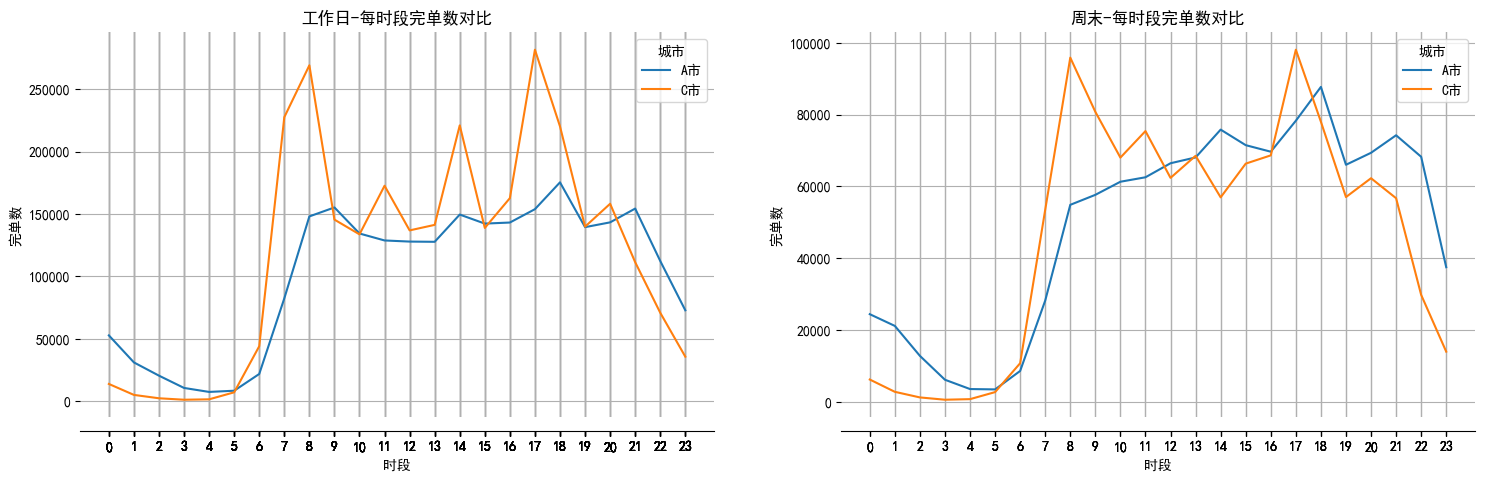

In [13]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']      # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False        # 用来正常显示负号

# 区分工作日和非工作日
workday = ca_city[~ca_city['星期'].isin(['周六','周日'])]
weekend = ca_city[ca_city['星期'].isin(['周六','周日'])]

fig = plt.figure(figsize=(18,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

sns.lineplot(data = workday.groupby(['城市','时段'])['完单数'].sum().reset_index(),x = '时段',y = '完单数',markers = 'o',hue = '城市',ax = ax1)
ax1.set_xticks(workday['时段'])
ax1.set_title('工作日-每时段完单数对比')
ax1.grid(True)

sns.lineplot(data = weekend.groupby(['城市','时段'])['完单数'].sum().reset_index(),x= '时段',y = '完单数',markers = 'o',hue = '城市',ax = ax2)
ax2.set_xticks(weekend['时段'])
ax2.set_title('周末-每时段完单数对比')
ax2.grid(True)

sns.despine(left=True,offset=10)

- **需求端洞察**：C市早晚高峰需求强烈；A市刚需用户少，偏好非工作时间出行。

#### (2)供给端

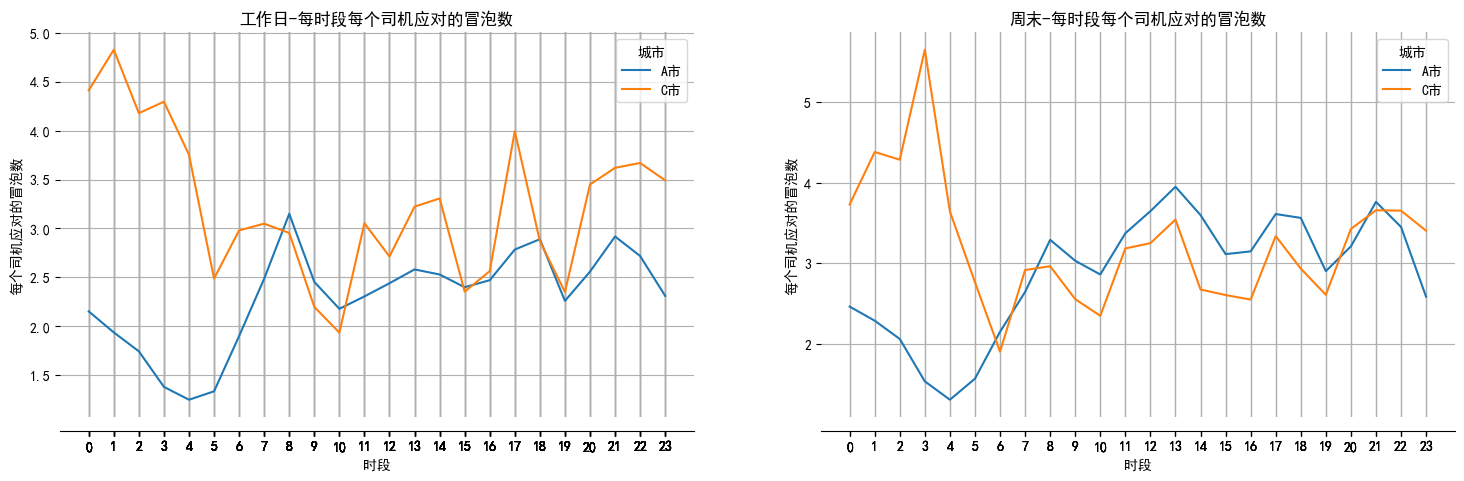

In [14]:
workday = workday.eval('每个司机应对的冒泡数 = 冒泡数/司机在线')
weekend = weekend.eval('每个司机应对的冒泡数 = 冒泡数/司机在线')

fig = plt.figure(figsize=(18,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

sns.lineplot(data = workday.groupby(['城市','时段'])['每个司机应对的冒泡数'].mean().reset_index(),x = '时段',markers='o',y = '每个司机应对的冒泡数',hue = '城市',ax = ax1)
ax1.set_xticks(workday['时段'])
ax1.set_title('工作日-每时段每个司机应对的冒泡数')
ax1.grid(True)

sns.lineplot(data = weekend.groupby(['城市','时段'])['每个司机应对的冒泡数'].mean().reset_index(),x = '时段',markers='o',y = '每个司机应对的冒泡数',hue = '城市',ax = ax2)
ax2.set_xticks(weekend['时段'])
ax2.set_title('周末-每时段每个司机应对的冒泡数')
ax2.grid(True)

sns.despine(left=True,offset=10)

- **供给端洞察**：C市司机供给更充足，高峰响应积极；A市兼职司机多，周末/高峰上线不足。

#### （3）C市周二发生了什么

对比可知：C市周二的最终转化率和应答率比其他日子都要低

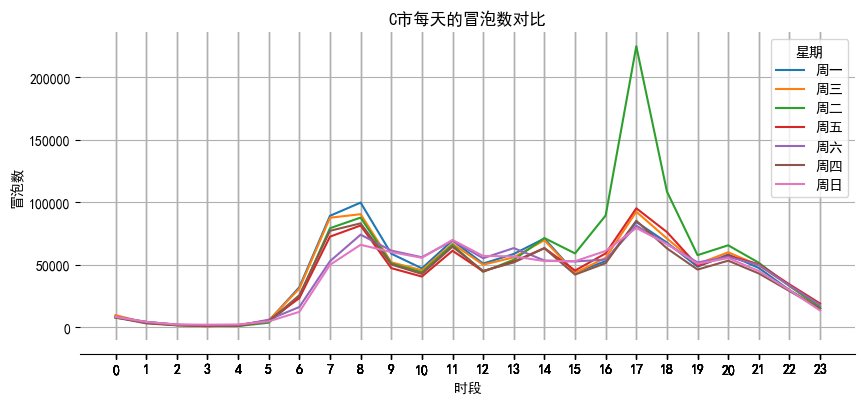

In [18]:
# 需求端：顾客冒泡数
c_city = df.query('城市 == "C市"')
plt.figure(figsize=(10,4))
sns.lineplot(data = c_city.groupby(['星期','时段'])['冒泡数'].sum().reset_index(),x = '时段',y = '冒泡数',markers='o',hue = '星期')
plt.xticks(c_city['时段'])
plt.title('C市每天的冒泡数对比')
plt.grid(True)
sns.despine(left=True,offset=10)

周二下午下班的高峰期用户人数激增，猜测和突发的恶劣天气有关

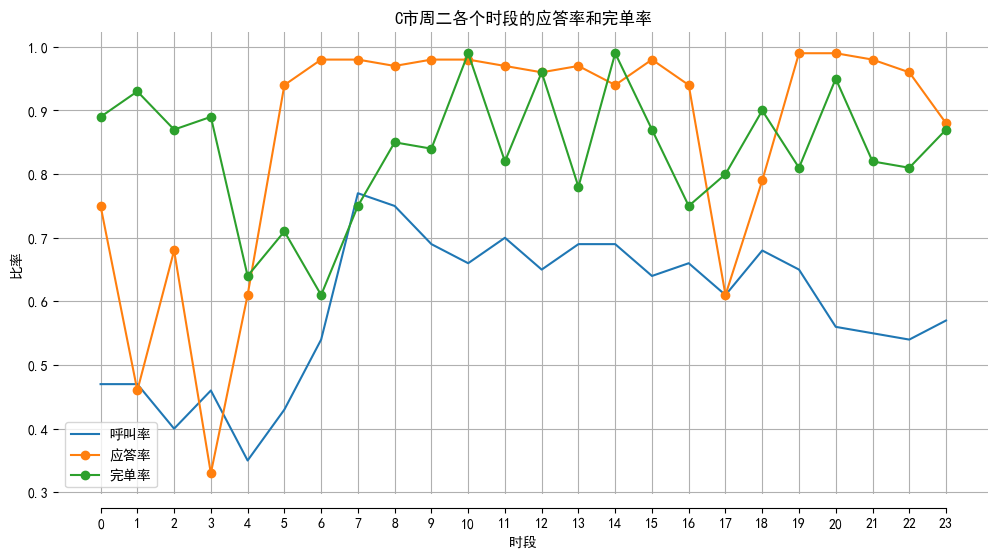

In [20]:
# 供给端
c_tuesday = df.query('星期 == "周二"').query('城市 == "C市"')
c_tuesday['呼叫率'] = round(c_tuesday['呼叫数']/c_tuesday['冒泡数'],2)
c_tuesday['应答率'] = round(c_tuesday['应答数']/c_tuesday['呼叫数'],2)
c_tuesday['完单率'] = round(c_tuesday['完单数']/c_tuesday['应答数'],2)
c_tuesday['最终转化率'] = round(c_tuesday['完单数']/c_tuesday['冒泡数'],2)
plt.figure(figsize=(12,6))
plt.plot(c_tuesday['时段'],c_tuesday['呼叫率'],label = '呼叫率')
plt.plot(c_tuesday['时段'],c_tuesday['应答率'],label = '应答率',marker = 'o')
plt.plot(c_tuesday['时段'],c_tuesday['完单率'],label = '完单率',marker = 'o')

plt.legend()#设置图例
plt.xticks(c_tuesday['时段'])# 设置横轴刻度
plt.xlabel('时段');plt.ylabel('比率')
plt.title('C市周二各个时段的应答率和完单率')
plt.grid(True)
sns.despine(trim = True,left = True,offset=10)

临时激增的需求导致周二17时的应答率和完单率骤降

In [22]:
#周二16-19时的应答率和完单率
c_tuesday_rush_hour = c_tuesday[c_tuesday['时段'].isin([16,17,18,19])][['星期','时段','应答率','完单率']]

#非周二
c_city['应答率'] = round(c_city['应答数']/c_city['呼叫数'],2)
c_city['完单率'] = round(c_city['完单数']/c_city['应答数'],2)
c_except_tuesday_rush_hour = c_city[~c_city['星期'].isin(['周二'])]
result = c_except_tuesday_rush_hour.groupby(['时段'])[['应答率','完单率']].agg('mean').reset_index()
result[['应答率','完单率']] = round(result[['应答率','完单率']],2)
result['星期'] = ['非周二']*24
result = result[result['时段'].isin([16,17,18,19])][['星期','时段','应答率','完单率']]

# 拼接表格
pd.merge(c_tuesday_rush_hour,result,on='时段',suffixes = ['(周二)','(非周二)'])

C:\Users\24677\AppData\Local\Temp\ipykernel_4660\3595125239.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_city['应答率'] = round(c_city['应答数']/c_city['呼叫数'],2)
C:\Users\24677\AppData\Local\Temp\ipykernel_4660\3595125239.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_city['完单率'] = round(c_city['完单数']/c_city['应答数'],2)


,星期(周二),时段,应答率(周二),完单率(周二),星期(非周二),应答率(非周二),完单率(非周二)
0,周二,16,0.94,0.75,非周二,0.98,0.87
1,周二,17,0.61,0.80,非周二,0.97,0.87
2,周二,18,0.79,0.90,非周二,0.98,0.85
3,周二,19,0.99,0.81,非周二,0.99,0.82


- **异常结论**：周二17时需求激增导致应答率骤降（0.61 vs 非周二0.97），是临时极端情况。

---

## 四、核心业务结论与建议
### 1. 城市表现总结
| 城市 | 核心表现 | 问题/优势 | 运营建议 |
|------|----------|-----------|----------|
| **C市** | 最终转化率最高，人均完单量最高 | 需求/供给适中，效率极高；周二高峰偶发应答不足 | 维持现有策略，优化周二高峰司机调度 |
| **A市** | 需求/供给最高，最终转化率最低 | 呼叫率低，刚需用户少，兼职司机多 | 重点挖掘早晚高峰刚需用户，优化司机激励，提升高峰上线率 |
| **B/D/E市** | 表现中庸 | 无明显短板/优势 | 对标C市优化转化流程，提升效率 |

### 2. 关键问题解读
- **低呼叫率**：用户货比三家、无车可叫或误触，需优化价格/运力展示
- **低应答率**：司机供给不足、竞争激烈或服务质量差，需增加司机供给/优化派单

---





## 五、多维度分析方法论总结
1.  **先理背景**：梳理指标关系（并列/包含/流程），避免盲目操作
2.  **遵循顺序**：`从大到小（大区→城市→星期→时段）` + `从尾到头（完单→应答→呼叫→冒泡）`
3.  **灵活组合**：结合比例法、整体结构法、漏斗分析法，逐步缩小范围
4.  **供需结合**：涉及供需关系时，后期引入供需分析，深入理解市场动态

---